# Using Graph Searches to Produce Matrix Inverse Algorithms

By Gabriel M. Perry, Micah H. Olson, David Grimsman, and Sean Warnick

In association with IDeA Labs, BYU, Provo, Utah, USA 84604

Colab Notebook by Gabriel Perry and Micah Olson

This Jupyter notebook is a companion illustration for our paper of the same title,
which can be found in the proceedings of the ***INSERT CONFERENCE HERE***.
The algorithms explained in that paper are implemented here for illustrative purposes, and we exerted little effort to optimize these implementations.
Our focus was on the production of matrix inverse algorithms by applying graph search algorithms to a flow graph $Q=I-M$.
In the paper, we discuss four algorithms:

* Depth-First Search produces Mason's gain formula
* Breadth-First Search produces a Taylor polynomial
* Priority Search introduces intermediate rounding
* Bidirectional Search introduces an in-horizon filter

Of particular note is our contribution, Bidirectional Search.
When we applied this graph search to the flow graph $Q$,
the resulting matrix inverse algorithm was not an intuitive variation on the other solutions.

This notebook is publicly available in association with the paper.
We are currently working with other algorithms in preparation for follow-up papers.
Anyone interested in this work can email Gabriel Perry at gmp99@byu.edu. We would also be interested in any feedback provided,
including optimization, clarification, or extensions of this set of algorithms.

## Auxillary Functions

In [ ]:
import numpy as np
import copy

In [ ]:
def show_plot(title, x, gauss, pow_, pri, bidir, step, show_gauss=False, _n=None, save_plot=False):
  plt.title(title)
  if show_gauss: plt.plot(x, gauss, label="Gaussian Elim.")
  plt.plot(x, pow_, label="Breadth-First")
  plt.plot(x, pri, label="Priority")
  plt.plot(x, bidir, label="Bidirectional")
  plt.ylabel("Log10 " + title)
  plt.xlabel("log10 size of the matrix n: Real n X n" if _n is None else "log10 sparcity of the matrix s: Real {} X {}".format(_n, _n))
  plt.legend()
  if save_plot:
    plt.savefig(f'{title} with n={n}.png', dpi=400)
  plt.show()

### Adjacency List Logic

In [ ]:
# @title generate an adjacency list (invertible matrix of size "size" with one to "num_out_edges" entries per column) with column sums "sum_of_each_column"
def generateSparseAdjacencyList(size, num_out_edges, sum_of_each_column, seed=None):
  if seed is not None:
    np.random.seed(seed)
  M_col = {}
  M_row = {}
  for i in range(size):
    # to guarantee the diagonal has some value in it, use {i:1}
    M_col[i] = {i:1}
    M_row[i] = {i:1}

  for cycle in range(num_out_edges):
    # generate num_out_edges permutations of size numbers
    perm = np.random.permutation(size)

    # each permutation is a path from prev to next, so the entries in the matrix are M[col][row] == M[perm[curr], perm[next]]
    # give these entries random values from -1 to 1
    for index in range(size):
      val = np.random.random()*2 - 1
      M_col[perm[index]][perm[(index+1)%size]] = val
      M_row[perm[(index+1)%size]][perm[index]] = val

  # normalize the columns after we are done to sum to sum_of_each_column
  for col in range(size):
    magnitude = np.sum(np.abs(list(M_col[col].values()))) / sum_of_each_column
    for row in M_col[col].keys():
      # Q needs to have spectral radius less than 1, not M
      val = (row==col) - M_col[col][row] / magnitude
      M_col[col][row] = val
      M_row[row][col] = val

  return M_row, M_col

In [ ]:
#@title Multiply a matrix[column, row] on the right by a column vector u
def dict_mat_mult(M, u, epsilon=0.0):
  y = {} # y = Mu
  FLOPs = 0
  for col in u.keys():
    if col not in M.keys():
      continue
    for row in M[col].keys():
      if row not in y.keys():
        y[row] = 0.0
      FLOPs += 1 # for multiplication
      y[row] += M[col][row] * u[col] # the column of M matches the row of u
      if abs(y[row]) <= epsilon:
        del y[row]
  return y, FLOPs

In [ ]:
#@title Add two vectors (adjacency lists)
def add_vects(left, right):
  for row in right.keys():
    if row not in left.keys():
      left[row] = right[row]
    else:
      left[row] += right[row]
  return left, len(right.keys())

In [ ]:
#@title A method for measuring norms of an ndarray
def measure(arr, norm=1):
  if np.size(arr) == 0:
    return 0.0
  if norm == 0:
    return np.count_nonzero(arr)
  if norm == 1:
    return np.sum(np.abs(arr))
  if norm == 2:
    return np.sum(np.square(arr)) # add np.abs on inside to use with complex numbers
  if norm == np.inf:
    return np.max(np.abs(arr))

def measure_dict_vect(vect, norm=1):
  return measure(list(vect.values()))

def measure_dict_mat(matrix, norm=1):
  magnitude = 0.0
  for key in matrix.keys():
    magnitude += measure_dict_vect(matrix[key], norm)
  if norm == 0:
    return int(magnitude)
  return magnitude

In [ ]:
#@title convert a dict to an ndarray
def dict_to_vect(vect, size):
  array = np.zeros((size,))
  for key in vect.keys():
    array[key] += vect[key]
  return array

def dict_to_mat(mat, size):
  array = np.zeros((size, size))
  for key in mat.keys():
    array[:,key] += dict_to_vect(mat[key], size)
  return array

In [ ]:
#@title On-the-fly access of Q given M, as well as a function for multiplying a vector by Q
def get_Q(M, row, col): # Q = I - M
  return (row == col) - M[col][row]

def mul_Q_left(M, vect, epsilon=0.0):
  y = {} # y = M * vect
  FLOPs = 0
  for col in vect.keys():
    for row in M[col].keys():
      if row not in y.keys():
        y[row] = 0.0
      y[row] += get_Q(M, row, col) * vect[col] # the column of M matches the row of vect
      FLOPs += 1
      if abs(y[row]) < epsilon:
        del y[row]
  return y, FLOPs

### Methods

In [ ]:
# @title Gaussian Elimination
# source: https://www.javatpoint.com/gaussian-elimination-in-python  (modified to work with adjacency lists)
def gaussian_inv_dict(M_dict, j, verbose=0):
  M = copy.deepcopy(M_dict)
  size = len(list(M.keys()))  # assume it is invertible, so every column has nonzero entries
  M[size] = {j:1}

  FLOPs = 0

  for pivot in range(0, size):
    # Searching the maximum value in the pivot column (don't count these FLOPs as a smarter method could do this live)
    max_el = 0
    max_row = pivot
    for row in M[pivot].keys():
      if row < pivot:
        continue
      if abs(M[pivot][row]) > max_el:
        max_el = abs(M[pivot][row])
        max_row = row

    # make the max row the pivot row (don't count these FLOPs as a smarter method could alias the operations in-place)
    for col in range(pivot, size+1):
      if max_row in M[col].keys():
        temp = M[col][max_row]
      else:
        temp = 0
      if pivot in M[col].keys():
        M[col][max_row] = M[col][pivot]
      else:
        if max_row in M[col].keys():
          del M[col][max_row]
      if temp != 0:
        M[col][pivot] = temp
      else:
        if pivot in M[col].keys():
          del M[col][pivot]

    # scale the pivot row to have 1-diagonal
    for col in range(size, pivot-1, -1):
      if pivot in M[col].keys():
        M[col][pivot] /= M[pivot][pivot]
        FLOPs += 1 # for division

    # Changing the value of the rows other than the diagonal (pivot) to 0 in the pivot column
    for row in M[pivot].keys():
      if row == pivot: # don't touch the pivot row
        continue

      leading = M[pivot][row]

      for col in range(size, pivot-1, -1):
        if row not in M[col].keys():
          M[col][row] = 0.0
        if pivot in M[col].keys():
          M[col][row] -= leading * M[col][pivot] # other rows, subtract pivot row scaled to make pivot column zero
          FLOPs += 2 # multiplication and subtraction

  return M[size], FLOPs, len(M_dict) # in O(n^3)

In [ ]:
# @title Power series with cutoff only (Breadth-First Search)
def pow_estimate_dict(M, j, max_iterations=10, epsilon=10**-3, verbose=0):
  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  FLOPs = 0
  COLS = set()

  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M, curr) # do not round
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure(list(curr.values()))
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon), mostly for practical purposes here
      break

  return u, FLOPs, len(COLS) # in O(i s n)

In [ ]:
# @title Power series with intermediate rounding (Priority Search)
def pow_estimate_epsilon_dict(M, j, max_iterations=10, epsilon=10**-3, verbose=0):
  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  FLOPs = 0
  COLS = set()

  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon)
      break

  return u, FLOPs, len(COLS) # in O(i s p)

In [ ]:
# @title Informed Power series (Bidirectional Search)
def bidir_dict(M_col, j, M_row, i, max_iterations=10, epsilon=10**-3, verbose=0):
  in_horiz = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {i:1} # e_j
  sqrt_epsilon = np.sqrt(epsilon)

  FLOPs = 0
  COLS = set()

  # find the sink in-horizon out to sqrt(epsilon)
  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M_row, in_horiz, epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    in_horiz, flops = add_vects(in_horiz, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_row, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"|| e_{i}^T Q^k|| = {magnitude:.4f}")
    if magnitude < sqrt_epsilon: # use sqrt epsilon as a cut off (if ||curr||_1 < sqrt epsilon, no entry is > sqrt epsilon)
      break

  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  # find the source out-horizon out to sqrt(epsilon)
  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M_col, u, epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_col, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    # COLS |= curr.keys() ################## ACTUALLY ROWS NOT COLUMNS - CAN OVER OR UNDERESTIMATE ########################

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < sqrt_epsilon: # use sqrt epsilon as a cut off (if ||curr||_1 < sqrt epsilon, no entry is > sqrt epsilon)
      break

  # continue the source out-horizon only within the sink in-horizon
  for iter in range(max_iterations):
    # round down everything in u not in the in-horizon
    for row in list(curr.keys()):
      if row not in in_horiz:
        del curr[row]

    if verbose > 1:
      print(dict_mat_mult(M_col,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_col, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon)
      break

  return u, FLOPs, len(COLS) # in O(i s sqrt(p))

### Test Drivers

In [ ]:
#@title A driver to help clean test code
def use_method(M_dict, size, method, **kwargs):
  M_inv = {}
  FLOPs = 0.0
  unique_cols = 0.0

  for col in range(size):
    u, flops, cols = method(M_dict, col, **kwargs)
    FLOPs += float(flops) / size
    unique_cols += float(cols) / size
    M_inv[col] = u

  M_inv = dict_to_mat(M_inv, size)
  Linf_error =  measure(dict_to_mat(M_dict, size) @ M_inv - np.identity(size), np.inf)
  if 'i' in kwargs:
    Linf_error =  measure((M_inv @ dict_to_mat(M_dict, size) - np.identity(size))[kwargs['i'],:], np.inf)

  return FLOPs, Linf_error, unique_cols, M_inv

In [ ]:
#@title Another test driver (runs all methods)
def run_all(M_row, M_col, n, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=1000, i=1, show_gauss=False):
  if show_gauss: FLOPs_gauss, Linf_error_gauss, unique_cols_gauss, M_inv_gauss = use_method(M_col, n, gaussian_inv_dict) # 21-37 sec for n=100, k=10
  else: FLOPs_gauss, Linf_error_gauss, unique_cols_gauss = -1, -1, -1
  FLOPs_pow, Linf_error_pow, unique_cols_pow, M_inv_pow = use_method(M_col, n, pow_estimate_dict, max_iterations=max_iterations, epsilon=pow_epsilon, verbose=0) # 4 sec for n=100, k=10
  FLOPs_pow_ep, Linf_error_pow_ep, unique_cols_pow_ep, M_inv_pow_ep = use_method(M_col, n, pow_estimate_epsilon_dict, max_iterations=max_iterations, epsilon=pri_epsilon, verbose=0) # 1 sec for n=100, k=10
  FLOPs_bidir, Linf_error_bidir, unique_cols_bidir, M_inv_bidir = use_method(M_col, n, bidir_dict, M_row=M_row, i=i, max_iterations=max_iterations, epsilon=bid_epsilon, verbose=0)
  return [[FLOPs_gauss, Linf_error_gauss, unique_cols_gauss],
          [FLOPs_pow, Linf_error_pow, unique_cols_pow],
          [FLOPs_pow_ep, Linf_error_pow_ep, unique_cols_pow_ep],
          [FLOPs_bidir, Linf_error_bidir, unique_cols_bidir]]

In [ ]:
#@title A more detailed matrix with transpose generator
# n: the size of the matrix
# s: the maximum number of nonzero entries in each column (we implemented the same bound for the row, so we can use bidirectional search)
# Q_spectral_radius: must be in [0, 1)
# rand_seed: if this is None, we generate a random matrix every time. We chose 0 arbitrarily, prior to computing the table data.
def setup_matrix(n, s, Q_spectral_radius=0.7, rand_seed=None, verbose=0):
  M_row, M_col = generateSparseAdjacencyList(n, s, Q_spectral_radius, rand_seed)

  if verbose > 1 and n < 4:
    print(M_col)
  Mr = dict_to_mat(M_row, n)
  Mc = dict_to_mat(M_col, n)
  Q = np.identity(n) - Mc
  Q_eigs = np.real(np.linalg.eigvals(Q))

  if verbose > 0:
    print("Spectral radius of Q is:", max(abs(Q_eigs)))
    print("Smallest Eigenvalue of Q is:", min(abs(Q_eigs)))
    print("Conditioning of Q is:", max(abs(Q_eigs)) / min(abs(Q_eigs)))
    print(f"Eigs of Q are in the interal [{np.min(Q_eigs):.4f}, {np.max(Q_eigs):.4f}] (must be in (-1,1))")
    print(f"Row wise matches Column wise: {not np.any(Mr.T - Mc)}") # are M_row and M_col actually the same matrix (double check)
  return M_row, M_col

In [ ]:
# @title Display Single-Run Fixed n Data using Pandas Dataframe
# 50s for (n=100, s=10, acc=1e-1)
# 55s for (n=200, s=10, epsilon=1e-5)
# max_iterations: a cap so we don't loop forever
import pandas as pd
def fixed_n_table(M_row, M_col, n, i, pow_epsilon, pri_epsilon, bid_epsilon, max_iterations=1000, verbose=0):
  if n <= 100:
    FLOPs_gauss, Linf_error_gauss, gauss_perc_fetched, M_inv_gauss = use_method(M_col, n, gaussian_inv_dict) # 21-37 sec for n=100, k=10
  else:
    FLOPs_gauss, Linf_error_gauss, gauss_perc_fetched, M_inv_gauss = 6 * n * n * s, 1e-15, 1, M_row # a bad estimate when the matrix is too big
  FLOPs_pow, Linf_error_pow, unique_cols_pow, M_inv_pow = use_method(M_col, n, pow_estimate_dict, max_iterations=max_iterations, epsilon=pow_epsilon, verbose=0) # 4 sec for n=100, k=10
  FLOPs_pow_ep, Linf_error_pow_ep, unique_cols_pow_ep, M_inv_pow_ep = use_method(M_col, n, pow_estimate_epsilon_dict, max_iterations=max_iterations, epsilon=pri_epsilon, verbose=0) # 1 sec for n=100, k=10
  FLOPs_bidir, Linf_error_bidir, unique_cols_bidir, M_inv_bidir = use_method(M_col, n, bidir_dict, M_row=M_row, i=i, max_iterations=max_iterations, epsilon=bid_epsilon, verbose=0)


  column_estimate_stats = pd.DataFrame(columns = ['Computed', 'Avg. FLOPs', '% of Gaussian Elim.', 'Avg. Linf Error'])

  column_estimate_stats.loc[len(column_estimate_stats.index)] = ['matrix', FLOPs_gauss, 1, Linf_error_gauss]
  column_estimate_stats.loc[len(column_estimate_stats.index)] = ['column', FLOPs_pow, FLOPs_pow/FLOPs_gauss, Linf_error_pow]
  column_estimate_stats.loc[len(column_estimate_stats.index)] = ['column', FLOPs_pow_ep, FLOPs_pow_ep/FLOPs_gauss, Linf_error_pow_ep]
  column_estimate_stats.loc[len(column_estimate_stats.index)] = ['entry', FLOPs_bidir, FLOPs_bidir/FLOPs_gauss, Linf_error_bidir]

  column_estimate_stats.index = [f'Gauss (no e)', f'Breadth (e={pow_epsilon})', f'Priority (e={pri_epsilon})', f'Bidirectional (e={bid_epsilon})']
  if verbose > 0:
    display(column_estimate_stats)

  return column_estimate_stats

In [ ]:
# @title Display Multi-Run Multi-n Data using Pyplot
# max_iterations: a cap so we don't loop forever
import matplotlib.pyplot as plt
from tqdm import tqdm
def multi_n_graph(sparcity=np.sqrt, Q_spectral_radius=0.7, max_n=10, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=1000, save_plot=False, show_gauss=False, step=1, verbose=0):
  from google.colab import drive
  drive.mount('/content/drive')

  x = []

  gauss_FLOPs = []
  pow_FLOPs = []
  pri_FLOPs = []
  bidir_FLOPs = []

  gauss_Linf_err = []
  pow_Linf_err = []
  pri_Linf_err = []
  bidir_Linf_err = []

  gauss_cols_fetched = []
  pow_cols_fetched = []
  pri_cols_fetched = []
  bidir_cols_fetched = []

  #import traceback
  try:
    cond_range = np.round(10**np.linspace(1, np.log10(max_n), 2*int(np.round(np.log10(max_n))))).astype(int)
    display(cond_range)
    for n in cond_range:
      print(n, end=", ")
      M_row, M_col = setup_matrix(n=n, s=int(sparcity(n)), Q_spectral_radius=0.7, rand_seed=None, verbose=verbose-1)

      data = run_all(M_row=M_row, M_col=M_col, n=n, pow_epsilon=pow_epsilon, pri_epsilon=pri_epsilon, bid_epsilon=bid_epsilon, max_iterations=max_iterations, show_gauss=show_gauss, i=i)
      x.append(np.log10(n))

      if show_gauss: gauss_FLOPs.append(np.log10(data[0][0]))
      pow_FLOPs.append(np.log10(data[1][0]))
      pri_FLOPs.append(np.log10(data[2][0]))
      bidir_FLOPs.append(np.log10(data[3][0]))

      if show_gauss: gauss_Linf_err.append(np.log10(data[0][1]))
      pow_Linf_err.append(np.log10(data[1][1]))
      pri_Linf_err.append(np.log10(data[2][1]))
      bidir_Linf_err.append(np.log10(data[3][1]))

      if show_gauss: gauss_cols_fetched.append(data[0][2])
      pow_cols_fetched.append(data[1][2])
      pri_cols_fetched.append(data[2][2])
      bidir_cols_fetched.append(data[3][2])

  except:
    #traceback.print_exc()
    print(f"Execution ended manually after {n} Iterations")
  finally:
    pass

  show_plot("Average Linf Error", x, gauss_Linf_err, pow_Linf_err, pri_Linf_err, bidir_Linf_err, step=step, show_gauss=show_gauss, save_plot=save_plot)
  show_plot("FLOPs Count", x, gauss_FLOPs, pow_FLOPs, pri_FLOPs, bidir_FLOPs, step=step, show_gauss=show_gauss, save_plot=save_plot)
  #show_plot("Avg Error per FLOP", x, np.array(gauss_Linf_err)-np.array(gauss_FLOPs), np.array(pow_Linf_err)-np.array(pow_FLOPs), np.array(pri_Linf_err)-np.array(pri_FLOPs), np.array(bidir_Linf_err)-np.array(bidir_FLOPs), step=step, show_gauss=show_gauss, save_plot=save_plot)
  show_plot("Avg Unique Columns Fetched", x, np.log10(gauss_cols_fetched), np.log10(pow_cols_fetched), np.log10(pri_cols_fetched), np.log10(bidir_cols_fetched), step=step, show_gauss=show_gauss, save_plot=save_plot)

In [ ]:
# @title Display Multi-Run Multi-n Data using Pyplot
# # max_iterations: a cap so we don't loop forever
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# def multi_n_graph(sparcity=np.sqrt, Q_spectral_radius=0.7, max_n=10, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=1000, save_plot=False, show_gauss=False, step=1, verbose=0):

#   x = []

#   gauss_FLOPs = []
#   pow_FLOPs = []
#   pri_FLOPs = []
#   bidir_FLOPs = []

#   gauss_Linf_err = []
#   pow_Linf_err = []
#   pri_Linf_err = []
#   bidir_Linf_err = []

#   gauss_cols_fetched = []
#   pow_cols_fetched = []
#   pri_cols_fetched = []
#   bidir_cols_fetched = []

#   #import traceback
#   try:
#     cond_range = [lambda x:x, tqdm] # lambda x:x is function that does nothing
#     r = range(max(2, step), max_n, step)
#     for n in cond_range[verbose](r):
#       M_row, M_col = setup_matrix(n=n, s=int(sparcity(n)), Q_spectral_radius=0.7, rand_seed=None, verbose=verbose-1)

#       data = run_all(M_row=M_row, M_col=M_col, n=n, pow_epsilon=pow_epsilon, pri_epsilon=pri_epsilon, bid_epsilon=bid_epsilon, max_iterations=max_iterations, show_gauss=show_gauss, i=i)
#       x.append(np.log10(n))

#       if show_gauss: gauss_FLOPs.append(np.log10(data[0][0]))
#       pow_FLOPs.append(np.log10(data[1][0]))
#       pri_FLOPs.append(np.log10(data[2][0]))
#       bidir_FLOPs.append(np.log10(data[3][0]))

#       if show_gauss: gauss_Linf_err.append(np.log10(data[0][1]))
#       pow_Linf_err.append(np.log10(data[1][1]))
#       pri_Linf_err.append(np.log10(data[2][1]))
#       bidir_Linf_err.append(np.log10(data[3][1]))

#       if show_gauss: gauss_cols_fetched.append(data[0][2])
#       pow_cols_fetched.append(data[1][2])
#       pri_cols_fetched.append(data[2][2])
#       bidir_cols_fetched.append(data[3][2])

#   except:
#     #traceback.print_exc()
#     print(f"Execution ended manually after {n} Iterations")
#   finally:
#     pass

#   show_plot("Average Linf Error", x, gauss_Linf_err, pow_Linf_err, pri_Linf_err, bidir_Linf_err, step=step, show_gauss=show_gauss, save_plot=save_plot)
#   show_plot("FLOPs Count", x, gauss_FLOPs, pow_FLOPs, pri_FLOPs, bidir_FLOPs, step=step, show_gauss=show_gauss, save_plot=save_plot)
#   #show_plot("Avg Error per FLOP", x, np.array(gauss_Linf_err)-np.array(gauss_FLOPs), np.array(pow_Linf_err)-np.array(pow_FLOPs), np.array(pri_Linf_err)-np.array(pri_FLOPs), np.array(bidir_Linf_err)-np.array(bidir_FLOPs), step=step, show_gauss=show_gauss, save_plot=save_plot)
#   show_plot("Avg Unique Columns Fetched", x, np.log10(gauss_cols_fetched), np.log10(pow_cols_fetched), np.log10(pri_cols_fetched), np.log10(bidir_cols_fetched), step=step, show_gauss=show_gauss, save_plot=save_plot)

In [ ]:
# @title Display Fixed-n Multi-s Data using Pyplot
import matplotlib.pyplot as plt
from tqdm import tqdm
def multi_s_graph(n, max_s, Q_spectral_radius=0.3, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=10000, save_plot=False, show_gauss=False, step=1, verbose=1):

  x = []

  gauss_FLOPs = []
  pow_FLOPs = []
  pri_FLOPs = []
  bidir_FLOPs = []

  gauss_Linf_err = []
  pow_Linf_err = []
  pri_Linf_err = []
  bidir_Linf_err = []

  gauss_cols_fetched = []
  pow_cols_fetched = []
  pri_cols_fetched = []
  bidir_cols_fetched = []

  try:
    cond_range = [lambda x:x, tqdm] # lambda x:x is function that does nothing
    r = range(1, max_s)
    for s in cond_range[verbose](r):
      M_row, M_col = setup_matrix(n=n, s=s, Q_spectral_radius=0.7, rand_seed=None, verbose=verbose-1)

      data = run_all(M_row=M_row, M_col=M_col, n=n, pow_epsilon=pow_epsilon, pri_epsilon=pri_epsilon, bid_epsilon=bid_epsilon, max_iterations=max_iterations, show_gauss=show_gauss, i=i)
      x.append(np.log10(s))

      if show_gauss: gauss_FLOPs.append(np.log10(data[0][0]))
      pow_FLOPs.append(np.log10(data[1][0]))
      pri_FLOPs.append(np.log10(data[2][0]))
      bidir_FLOPs.append(np.log10(data[3][0]))

      if show_gauss: gauss_Linf_err.append(np.log10(data[0][1]))
      pow_Linf_err.append(np.log10(data[1][1]))
      pri_Linf_err.append(np.log10(data[2][1]))
      bidir_Linf_err.append(np.log10(data[3][1]))

      if show_gauss: gauss_cols_fetched.append(np.log10(data[0][2]))
      pow_cols_fetched.append(np.log10(data[1][2]))
      pri_cols_fetched.append(np.log10(data[2][2]))
      bidir_cols_fetched.append(np.log10(data[3][2]))

  except:
    print(f"Execution ended manually after {s} Iterations")
  finally:
    pass

  show_plot("Average Linf Error", x, gauss_Linf_err, pow_Linf_err, pri_Linf_err, bidir_Linf_err, step=step, show_gauss=show_gauss, _n=n, save_plot=save_plot)
  show_plot("FLOPs Count", x, gauss_FLOPs, pow_FLOPs, pri_FLOPs, bidir_FLOPs, step=step, show_gauss=show_gauss, _n=n,  save_plot=save_plot)
  show_plot("Avg Unique Columns Fetched", x, gauss_cols_fetched, pow_cols_fetched, pri_cols_fetched, bidir_cols_fetched, step=step, show_gauss=show_gauss, _n=n,  save_plot=save_plot)

In [ ]:
#@title Append to a File
import pandas as pd
import numpy as np
def sample_and_save(num_samples, filename='/content/drive/My Drive/samples.csv', sparcity=np.sqrt, Q_spectral_radius=0.7, max_n=10, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=1000, save_plot=False, show_gauss=False, step=1, verbose=0):
  from google.colab import drive
  drive.mount('/content/drive')
  """
  Takes samples and appends results to a file on Google Drive.
  Can load previous run and continue adding samples.

  Args:
    num_samples: Number of samples to take.
    filename: Path to the file on Google Drive.
  """

  try:
    # Try to load existing data
    df = pd.read_csv(filename)
  except FileNotFoundError:
    # Create a new DataFrame if file doesn't exist
    df = pd.DataFrame()

  try:
    for n in 10 + np.random.exponential(scale=max_n, size=num_samples):
      n,s = int(n), int(sparcity(n))
      print(f"n={n}, s={s}")
      M_row, M_col = setup_matrix(n=n, s=s, Q_spectral_radius=0.7, rand_seed=None, verbose=verbose-1)

      data = run_all(M_row=M_row, M_col=M_col, n=n, pow_epsilon=pow_epsilon, pri_epsilon=pri_epsilon, bid_epsilon=bid_epsilon, max_iterations=max_iterations, show_gauss=show_gauss, i=i)

      column_estimate_stats = pd.DataFrame(columns = ['Computed', 'n', 's', 'Avg. FLOPs', 'Cols Fetched', 'Avg. Linf Error'])

      if show_gauss:
        column_estimate_stats.loc[len(column_estimate_stats.index)] = ['Gauss', n, s, np.log10(data[0][0]), np.log10(data[0][2]), np.log10(data[0][1])]
      column_estimate_stats.loc[len(column_estimate_stats.index)] = ['Power', n, s, np.log10(data[1][0]), np.log10(data[1][2]), np.log10(data[1][1])]
      column_estimate_stats.loc[len(column_estimate_stats.index)] = ['Priority', n, s, np.log10(data[2][0]), np.log10(data[2][2]), np.log10(data[2][1])]
      column_estimate_stats.loc[len(column_estimate_stats.index)] = ['Bidir', n, s, np.log10(data[3][0]), np.log10(data[3][2]), np.log10(data[3][1])]

      # Append sample to DataFrame
      df = pd.concat((df, column_estimate_stats), ignore_index=True)

      # Save updated DataFrame to Google Drive
      df.to_csv(filename, index=False)

  except:
    print(f"Execution ended manually after {n} Iterations")
  finally:
    pass

  print(f"Saved {num_samples} samples to {filename}")


## Benchmark

In [ ]:
#@title Parameters
n = 200 # the size of fixed matrices
s = 3 # the fixed maximum number of nonzero entries in each column (we implemented the same bound for the row, so we can use bidirectional search)
Q_spectral_radius = 0.7 # the maximaum eigenvalue of Q (< 1)

max_n = 100000 # for range tests, the upper limit of sizes using the sparcity function
num_steps_n = 10 # number of sample points for range tests
max_s = 10  # for range tests, the upper limit of sparcities using the fixed n
num_steps_s = max_s # number of sample points for range tests

sparcity_func = lambda x:int(1+np.log10(x)) # np.sqrt # try = (lambda x:4) for a very sparse matrix

download = True # toggle this to True to save plots to your local machine
filename='/content/drive/My Drive/samples2.csv'

In [ ]:
sample_and_save(500, max_n=2000, sparcity=sparcity_func, filename=filename)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
n=1126, s=4
Execution ended manually after 1126 Iterations
Saved 500 samples to /content/drive/My Drive/samples2.csv


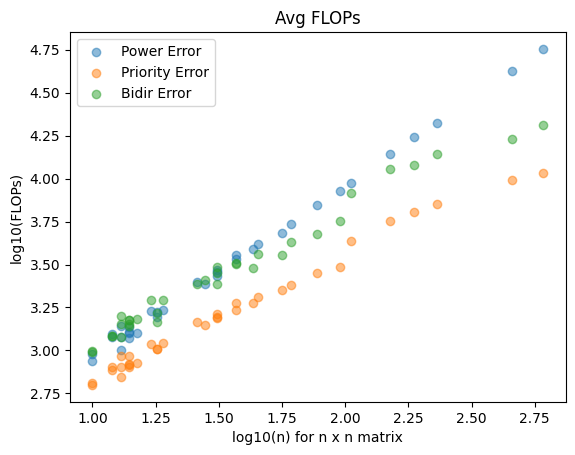

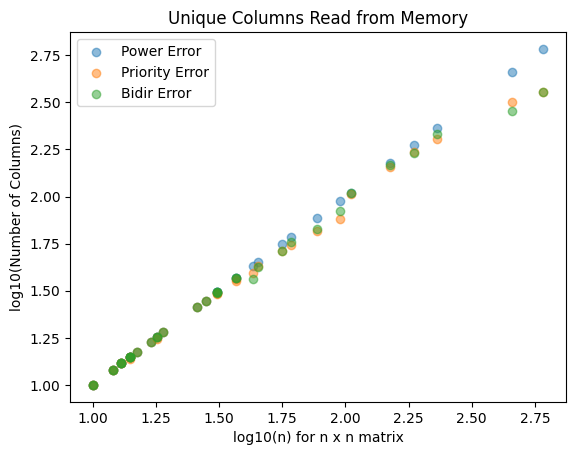

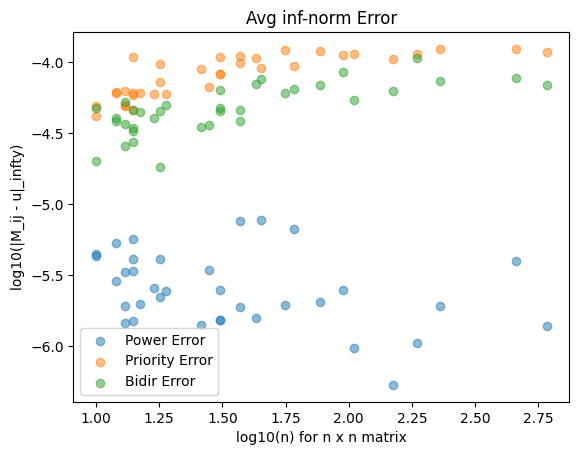

In [ ]:
df = pd.read_csv(filename)
alpha = 0.5

plt.title("Avg FLOPs")
plt.xlabel("log10(n) for n x n matrix")
plt.ylabel("log10(FLOPs)")
plt.scatter(np.log10(df[df['Computed'] == 'Power']['n']), df[df['Computed'] == 'Power']['Avg. FLOPs'], alpha=alpha, label='Power Error')
plt.scatter(np.log10(df[df['Computed'] == 'Priority']['n']), df[df['Computed'] == 'Priority']['Avg. FLOPs'], alpha=alpha, label='Priority Error')
plt.scatter(np.log10(df[df['Computed'] == 'Bidir']['n']), df[df['Computed'] == 'Bidir']['Avg. FLOPs'], alpha=alpha, label='Bidir Error')
plt.legend()
plt.show()

plt.title("Unique Columns Read from Memory")
plt.xlabel("log10(n) for n x n matrix")
plt.ylabel("log10(Number of Columns)")
plt.scatter(np.log10(df[df['Computed'] == 'Power']['n']), df[df['Computed'] == 'Power']['Cols Fetched'], alpha=alpha, label='Power Error')
plt.scatter(np.log10(df[df['Computed'] == 'Priority']['n']), df[df['Computed'] == 'Priority']['Cols Fetched'], alpha=alpha, label='Priority Error')
plt.scatter(np.log10(df[df['Computed'] == 'Bidir']['n']), df[df['Computed'] == 'Bidir']['Cols Fetched'], alpha=alpha, label='Bidir Error')
plt.legend()
plt.show()

plt.title("Avg inf-norm Error")
plt.xlabel("log10(n) for n x n matrix")
plt.ylabel("log10(|M_ij - u|_infty)")
plt.scatter(np.log10(df[df['Computed'] == 'Power']['n']), df[df['Computed'] == 'Power']['Avg. Linf Error'], alpha=alpha, label='Power Error')
plt.scatter(np.log10(df[df['Computed'] == 'Priority']['n']), df[df['Computed'] == 'Priority']['Avg. Linf Error'], alpha=alpha, label='Priority Error')
plt.scatter(np.log10(df[df['Computed'] == 'Bidir']['n']), df[df['Computed'] == 'Bidir']['Avg. Linf Error'], alpha=alpha, label='Bidir Error')
plt.legend()
plt.show()

array([    10,     28,     77,    215,    599,   1668,   4642,  12915,
        35938, 100000])

10, 28, 77, 215, 599, 1668, Execution ended manually after 1668 Iterations


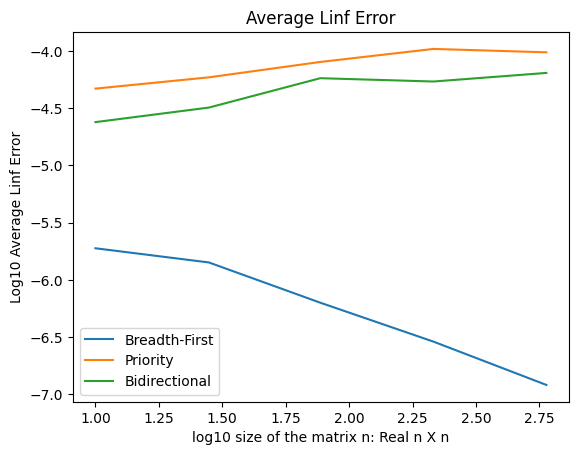

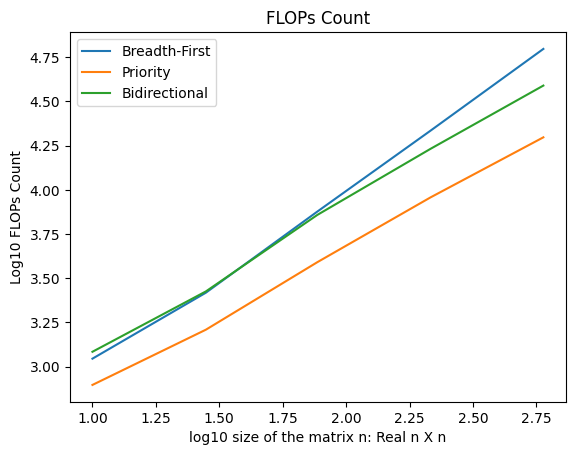

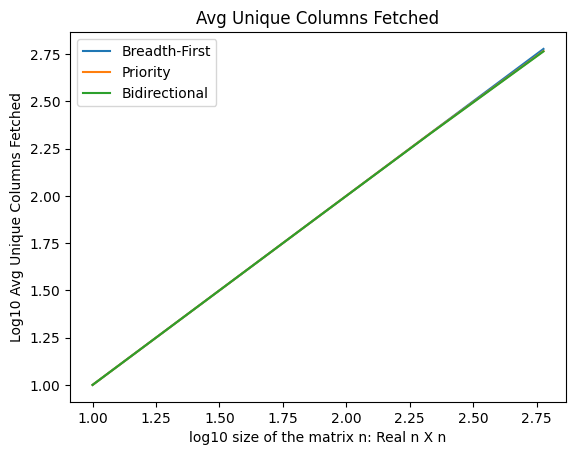

In [ ]:
#@title Display Multi-Run Multi-n Data using Pyplot
multi_n_graph(sparcity=sparcity_func, Q_spectral_radius=Q_spectral_radius, max_n=max_n, i=1,
              pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=10000, save_plot=download,
              step=max_n//num_steps_n, verbose=1)

# The default tqdm progress is deceptive, as the last few matrices take the most time (we could change this by adding a quadratic or cubic progress increment).
# one iteration/matrix of size (n x n) takes about n/8 seconds for n < 1000

 22%|██▏       | 2/9 [00:25<01:27, 12.53s/it]


Execution ended manually after 3 Iterations


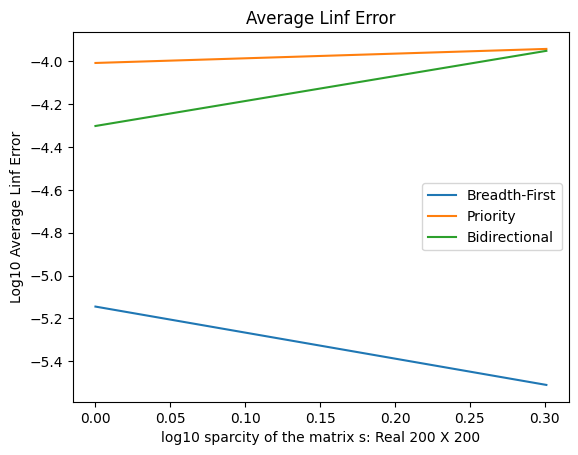

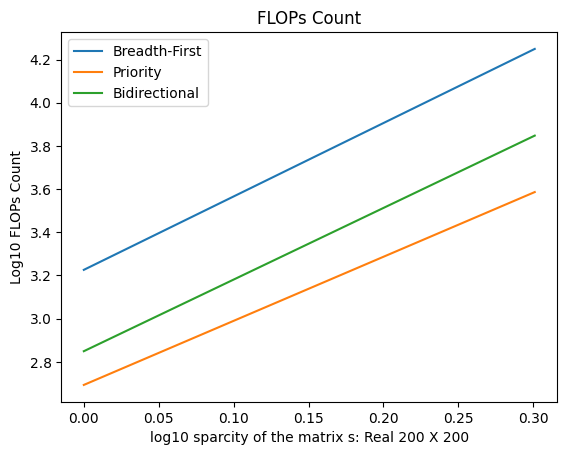

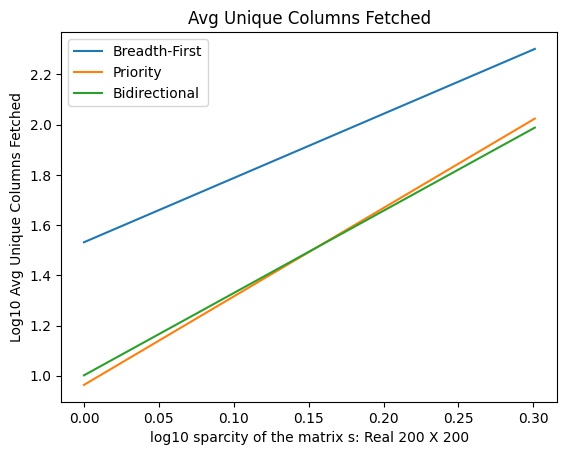

In [ ]:
# @title Display Fixed-n Multi-s Data using Pyplot
multi_s_graph(n=n, max_s=max_s, Q_spectral_radius=Q_spectral_radius, i=1,
              pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=10000,
              save_plot=download, verbose=1)

In [ ]:
# @title Download from Colab to local machine
if download:
  from google.colab import files
  for title in ["FLOPs Count", "FLOPs % of Gaussian", "Average Linf Error", "Avg Error per FLOP"]:
    files.download(f'{title} with n={max_n-1}.png')
    files.download(f'{title} with n={n} s={max_s-1}.png')

In [ ]:
# @title Display Single-Run Data using Pandas Dataframe

print(f"Showing results for one run using n={n}, s={s}")

# Set Up Test Matrix
M_row, M_col = setup_matrix(n=n, s=s, Q_spectral_radius=Q_spectral_radius, rand_seed=None, verbose=1)
print(M_row)
# These epslons have been fine-tuned to give the same average error in the output (M @ estimate).
# This helps to illustrate the sensitivity of each algorithm (how well it does given an epsilon)
# as well as how many FLOPs are actually needed to get an output accuracy
column_estimate_stats = fixed_n_table(M_row=M_row, M_col=M_col, n=n, i=1, pow_epsilon=2e-4, pri_epsilon=3e-7, bid_epsilon=5e-7, max_iterations=1000, verbose=1)

# these epsilons show what the algorithms do given the same epsilons
column_estimate_stats2 = fixed_n_table(M_row=M_row, M_col=M_col, n=n, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=1000, verbose=1)

Showing results for one run using n=200, s=3
Spectral radius of Q is: 0.5754490671863024
Smallest Eigenvalue of Q is: 0.025066684394368103
Conditioning of Q is: 22.956728466074768
Eigs of Q are in the interal [0.0251, 0.5754] (must be in (-1,1))
Row wise matches Column wise: True
{0: {0: 0.7188766229783641, 177: -0.118752470638531, 104: -0.2187587814836503, 107: 0.2966848626644833}, 1: {1: 0.6759502706345641, 94: 0.09612520120291142, 64: -0.12581584926629716, 171: -0.12336977396407249}, 2: {2: 0.45918735308088254, 122: 0.20207038697898377, 23: -0.24838975180807327, 116: -0.15059657141941443}, 3: {3: 0.7215218845065531, 15: 0.06902062578695134, 177: -0.23066896658209765, 161: -0.1910262827224209}, 4: {4: 0.6636951396042585, 185: 0.0409179842504698, 137: 0.113537350067088, 77: 0.11094314668281771}, 5: {5: 0.7534047804642634, 151: -0.17979699561065374, 4: 0.28577261219299066, 76: -0.19851244069497914}, 6: {6: 0.6849840552403896, 49: 0.047869728152635994, 61: 0.209846377577566, 8: -0.12355

KeyboardInterrupt: 

In [ ]:
column_estimate_stats.drop(columns=['Computed', '% of Gaussian Elim.'])

In [ ]:
column_estimate_stats2.drop(columns=['Computed', '% of Gaussian Elim.'])